Modified based on tutorial https://landlab.readthedocs.io/en/latest/tutorials/fault_scarp/landlab-fault-scarp.html

TO DO:
- Double check time stepping 
- Double check total time 

In [49]:
%load_ext autoreload
%autoreload 2

import utils
import numpy as np
import matplotlib.pyplot as plt
from landlab import RasterModelGrid
from landlab.plot.imshow import imshow_grid

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
fault_offsets = [1,2,3,4,5]
coeffs = [[] for _ in fault_offsets] 


In [54]:
for fault_idx, fault_offset in enumerate(fault_offsets):  
    mg = RasterModelGrid((25, 40), 10.0)
    z = np.random.rand(mg.size("node"))  # random noise for initial topography
    mg.add_field("topographic__elevation", z, at="node")

    # z = np.random.rand(mg.size("node"))  # random noise for initial topography
    fault_trace_y = 120.0 #+ 0.25 * mg.x_of_node
    z[mg.y_of_node > fault_trace_y] += (
        fault_offset
    )
    z_t0 = z[mg.nodes]
    slope_t0 = mg.calc_slope_at_node(z)
    slope_t0 = np.array(slope_t0)
    # plot DEM at time 0 
    imshow_grid(mg, "topographic__elevation")
    D = 0.001  # m2/yr transport coefficient
    dt = 0.2 * 0.5 * 0.5 / D # default time step is 50 years 
    mg.set_closed_boundaries_at_grid_edges(True, True, True, True)
    qs = mg.add_zeros("sediment_flux", at="link")
    n_iter = np.array(
        [0, 2, 20, 100, 200]
    )  # number of iterations (total_time = n_iter * dt) at which to produce output, default dt=50 years for linear problem

    plot_counter=0
    years = []
    coeff = []
    for p in range(max(n_iter)+1):
        if np.any(p == n_iter):
            slope_t = mg.calc_slope_at_node(z)
            slope_t = np.array(slope_t)
            # estiamte deg coefficient 
            coeffs[fault_idx].append(utils.estimate_degradation_coefficient_noplot(slope_t0,slope_t))
            z_t = z[mg.nodes]
            years.append(p*dt)
            plt.figure()
            plt.imshow(np.array(z_t)-np.array(z_t0))
            plt.colorbar()
            plt.title(p*dt)
            
        g = mg.calc_grad_at_link(z)
        qs[mg.active_links] = -D * g[mg.active_links]
        dzdt = -mg.calc_flux_div_at_node(qs)
        z[mg.core_nodes] += dzdt[mg.core_nodes] * dt  
        plt.close()

ValueError: x and y must be the same size

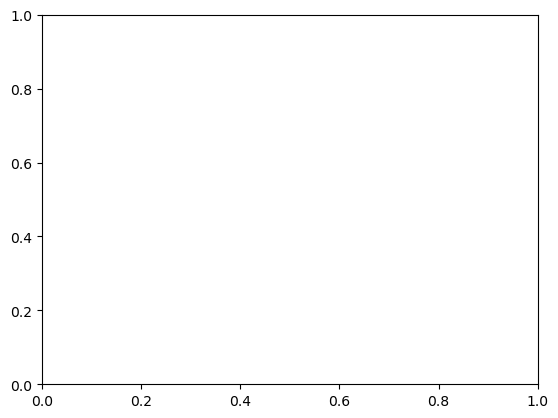

In [57]:
for i, fault_offset in enumerate(fault_offsets):
    plt.scatter(n_iter * dt, coeffs[i], label=f'Scarp = {fault_offset} m')


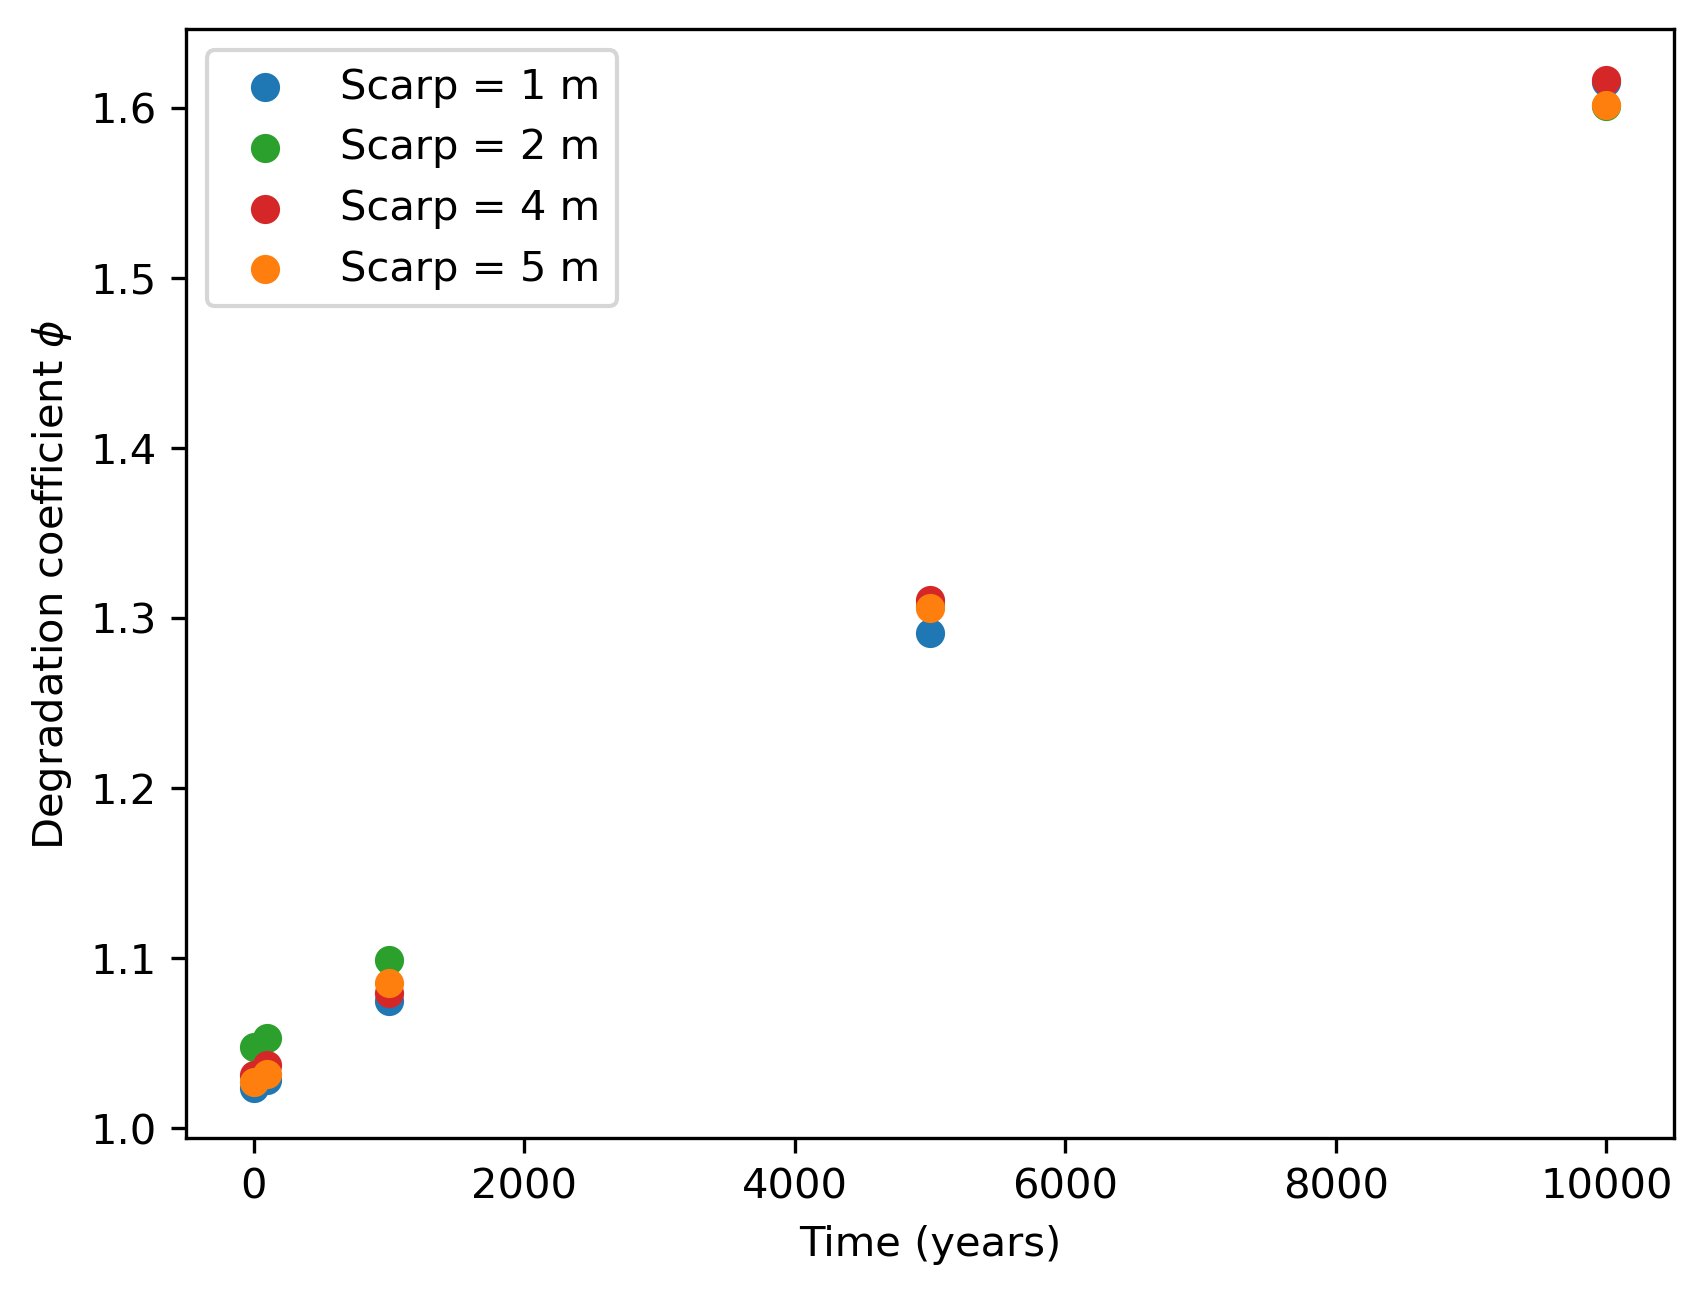

In [55]:
plt.figure(dpi=300)
plt.scatter(years,coeff_1m,c='tab:blue',label='Scarp = 1 m')
plt.scatter(years,coeff_2m,c='tab:green',label='Scarp = 2 m')
# plt.scatter(years,coeff_3m,c='tab:red',label='Scarp = 3 m')
plt.scatter(years,coeff_4m,c='tab:red',label='Scarp = 4 m')
plt.scatter(years,coeff_5m,c='tab:orange',label='Scarp = 5 m')
plt.ylabel(r'Degradation coefficient $\phi$')
plt.xlabel('Time (years)')
plt.legend()